In [ ]:
%load_ext autoreload
%autoreload 2

Imports

In [69]:
import os
import pandas as pd
from data.creation_bdd_mains import parse_file, parse_folder
from data.creation_bdd_tournois import parse_folder_resume
from data.tri_dossier import trier_fichiers
from src.ranges import range, affichage_range
from data.chargement_txt import load_data_from_s3
from src.decision_par_position import analyse_stack_bb
from src.prediction import feature_engineering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.formula.api as smf
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

Import des données

In [2]:
PROJECT_DIR = os.getcwd()

load_data_from_s3(
    project_dir=PROJECT_DIR,
    s3_path="mathiskacer2/diffusion/projet_poker/history.zip"
)

trier_fichiers("data/historique/history/", "data/mains/", "data/resumes/")


['history', '__MACOSX']


In [3]:
tableau_mains = parse_folder ("data/mains/")
tableau_tournoi = parse_folder_resume("data/resumes/")

tableau_mains.shape
tableau_tournoi.shape

(1925, 8)

In [4]:
tableau_mains.head()
#tableau_tournoi.head()

print(tableau_mains.columns.tolist())

['tournament', 'buy_in_price', 'buy_in_rake', 'buy_in_total', 'level', 'hand_id', 'id_table', 'numero_main', 'sequence', 'sb', 'bb', 'datetime', 'id_tournoi', 'hero', 'hero_seat', 'stack_start', 'total_players', 'position', 'stack_bb', 'cartes', 'main', 'fold_preflop', 'allin_preflop', 'flop', 'turn', 'river', 'saw_flop', 'saw_turn', 'saw_river', 'went_to_showdown', 'won_at_showdown', 'total_pot', 'gain', 'gain bb', 'benefice net', 'benefice bb', 'source_file']


Affichage des ranges

'metric' peut être :
- 'mean' si on veut un estimateur de l'espérance pour chaque main
- 'var' si on veut la volatilité pour chaque main
- 'freq' si on veut la fréquence d'ouverture de chaque main 

\
'hero' est le nom du joueur dont on veut afficher la range


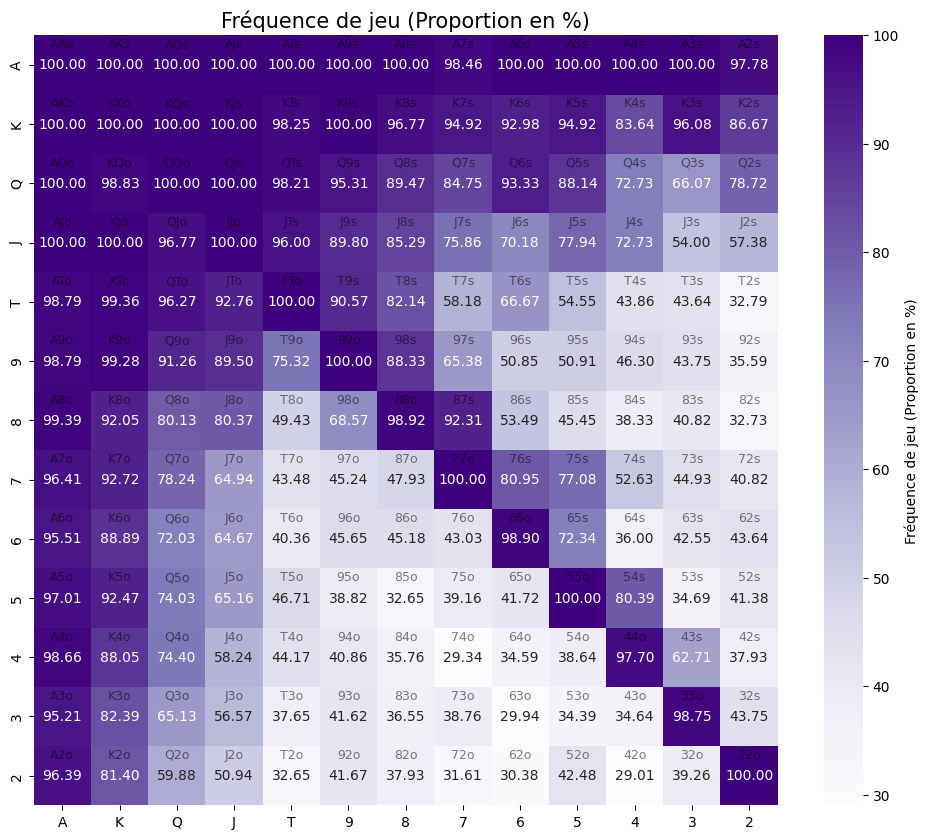

In [8]:
affichage_range(tableau_mains, metric='freq', hero='MathisKcr')

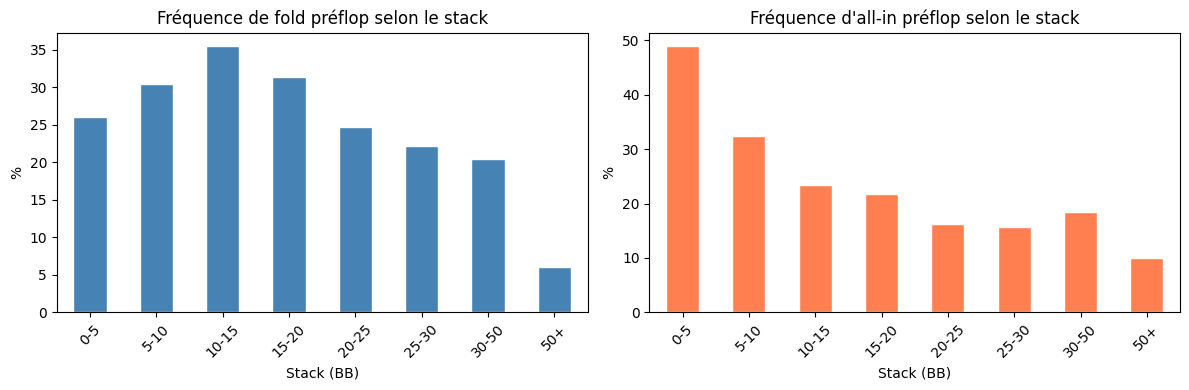

,nb_mains,fold_pf_pct,allin_pf_pct
stack_bb_range,,,
0-5,1940,0.261,0.489
5-10,4315,0.305,0.324
10-15,6747,0.355,0.234
15-20,2756,0.314,0.217
20-25,1392,0.247,0.162
25-30,528,0.222,0.157
30-50,569,0.204,0.185
50+,50,0.060,0.100


In [28]:
analyse_stack_bb(tableau_mains)

Prédiction

preprocessing

In [56]:
mains_select = feature_engineering(tableau_mains)

var_numeriques = ['stack_bb', 'level', 'carte haute', 'carte basse']
var_categorielles = ['position', 'est une paire', 'est meme signe', 'se suivent']

mains_select = mains_select[['benefice bb', 'main_gagnante']\
                                    + var_numeriques + var_categorielles + ['main', 'hero']]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), var_numeriques),
    ('cat', OneHotEncoder(handle_unknown='ignore'), var_categorielles)
])

mains_select.head()

,benefice bb,main_gagnante,stack_bb,level,carte haute,carte basse,position,est une paire,est meme signe,se suivent,main,hero
0,0.0,0,25.0,1,6,3,BTN,0,0,0,63o,MathisKcr
1,-1.0,0,25.0,1,8,4,BB,0,0,0,84o,MathisKcr
2,-1.0,0,24.0,1,10,9,SB,0,0,1,T9o,MathisKcr
3,1.5,1,23.0,1,14,10,BTN,0,0,0,ATo,MathisKcr
4,-1.0,0,24.5,1,10,9,BB,0,0,1,T9o,MathisKcr


Regression

In [ ]:
def regression(var_interet, var_auxiliaires, hero):
    reg_pipeline = Pipeline([
        ('prepro', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=4))
    ])

    mains_prediction = mains_select[mains_select['hero'] == hero]
    X = mains_prediction[var_auxiliaires]
    y_reg = mains_prediction[var_interet]

    X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

    reg_pipeline.fit(X_train, y_train)
    y_pred_reg = reg_pipeline.predict(X_test)

    print(f"R² Score: {r2_score(y_test, y_pred_reg):.4f}")
    print(f"Erreur Moyenne (MAE): {mean_absolute_error(y_test, y_pred_reg):.2f} BB")

regression('benefice bb', var_numeriques + var_categorielles, 'MathisKcr')


R² Score: 0.0164
Erreur Moyenne (MAE): 2.91 BB


Au départ, on obtenait un R2 négatif, cela est dû à la volatilité très forte et 
l'aléatoire présents dans le poker. \
Nous avons donc décidé de réduire la profondeur maximale (à 4). Ainsi nous obtenons 
un R2 de 0.016. Cela reste très faible. Nous allons donc essayer \
Un arbre associé est affiché ici :

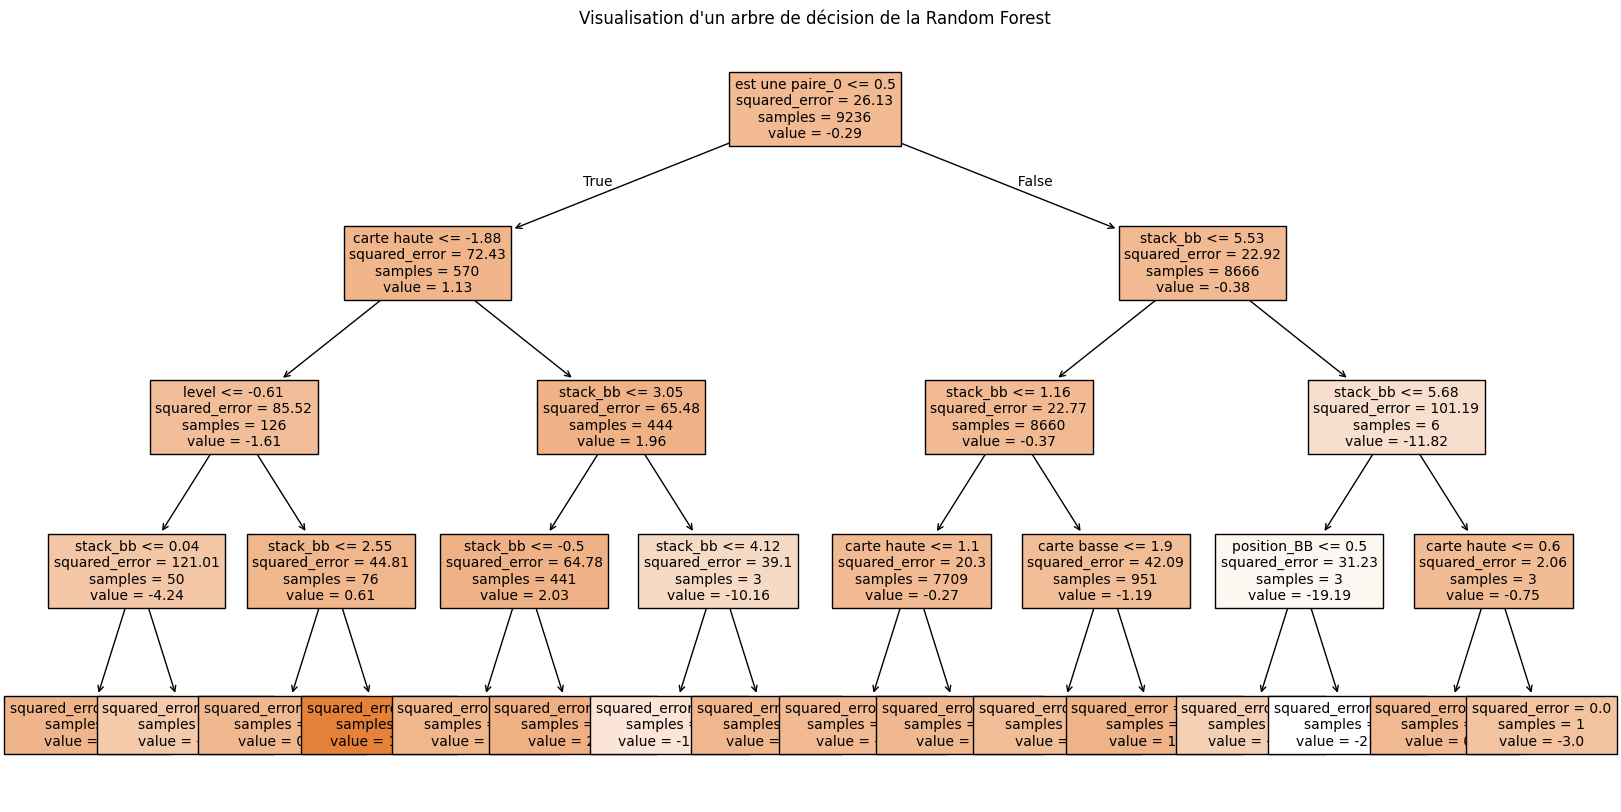

In [ ]:
ohe_feature_names = reg_pipeline.named_steps['prepro'].named_transformers_['cat'].get_feature_names_out(var_categorielles)
all_feature_names = var_numeriques + list(ohe_feature_names)

arbre_a_afficher = reg_pipeline.named_steps['regressor'].estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(arbre_a_afficher,
          feature_names=all_feature_names,
          filled=True,
          precision=2,
          fontsize=10,
          max_depth=4)
plt.title("Visualisation d'un arbre de décision de la Random Forest")
plt.show()

Régression linéaire

In [ ]:

def regression_ols(formule, hero):
    mains_stats = mains_select.rename(columns={'benefice bb': 'benefice_bb',
                                                'stack_bb': 'stack_bb',
                                                'carte haute': 'carte_haute',
                                                'carte basse': 'carte_basse',
                                                'est meme signe': 'est_meme_signe',
                                                'se suivent': 'se_suivent'})

    mains_stats = mains_stats[mains_stats['hero'] == hero]

    # Création du modèle OLS (Ordinary Least Squares)
    model = smf.ols(formula=formule, data=mains_stats)

    # Entraînement (ajustement)
    results = model.fit()

    return results.summary()

formule = "benefice_bb ~ stack_bb + carte_haute + carte_basse + C(est_meme_signe)" \
    "+ C(se_suivent) + level + C(position)"

print(regression_ols(formule, 'MathisKcr'))

                            OLS Regression Results                            
Dep. Variable:            benefice_bb   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     12.84
Date:              mar., 21 avr. 2026   Prob (F-statistic):           1.37e-18
Time:                        21:47:21   Log-Likelihood:                -55818.
No. Observations:               18297   AIC:                         1.117e+05
Df Residuals:                   18288   BIC:                         1.117e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

En supprimant les variables non significatives (P>0.05) :

In [51]:
formule = "benefice_bb ~ stack_bb + carte_basse + C(est_meme_signe)" \
"+ C(se_suivent)"

print(regression_ols(formule, 'MathisKcr'))

                            OLS Regression Results                            
Dep. Variable:            benefice_bb   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     25.08
Date:              mar., 21 avr. 2026   Prob (F-statistic):           9.56e-21
Time:                        21:40:10   Log-Likelihood:                -55819.
No. Observations:               18297   AIC:                         1.116e+05
Df Residuals:                   18292   BIC:                         1.117e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

Classification

In [76]:
def classification(hero):

    mains_prediction = mains_select[mains_select['hero'] == hero]

    X = mains_prediction[var_numeriques + var_categorielles]
    y_class = mains_prediction['main_gagnante']
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

    classif_pipeline = Pipeline([
        ('prepro', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5))
    ])

    classif_pipeline.fit(X_train_c, y_train_c)
    y_pred_c = classif_pipeline.predict(X_test_c)

    print(classification_report(y_test_c, y_pred_c))
    print(f"AUC Score: {roc_auc_score(y_test_c, classif_pipeline.predict_proba(X_test_c)[:, 1]):.2f}")

    return (y_test_c, y_pred_c)

classification('MathisKcr')

              precision    recall  f1-score   support

           0       0.71      0.76      0.73      2144
           1       0.62      0.56      0.59      1516

    accuracy                           0.68      3660
   macro avg       0.67      0.66      0.66      3660
weighted avg       0.67      0.68      0.68      3660

AUC Score: 0.74


(3571     0
 16592    0
 16533    1
 5245     1
 16339    0
         ..
 8452     0
 15031    0
 7969     0
 9981     0
 12372    1
 Name: main_gagnante, Length: 3660, dtype: int64,
 array([0, 0, 0, ..., 0, 0, 1], shape=(3660,)))

La matrice de confusion est donnée :

              precision    recall  f1-score   support

           0       0.71      0.76      0.73      2144
           1       0.62      0.56      0.59      1516

    accuracy                           0.68      3660
   macro avg       0.67      0.66      0.66      3660
weighted avg       0.67      0.68      0.68      3660

AUC Score: 0.74


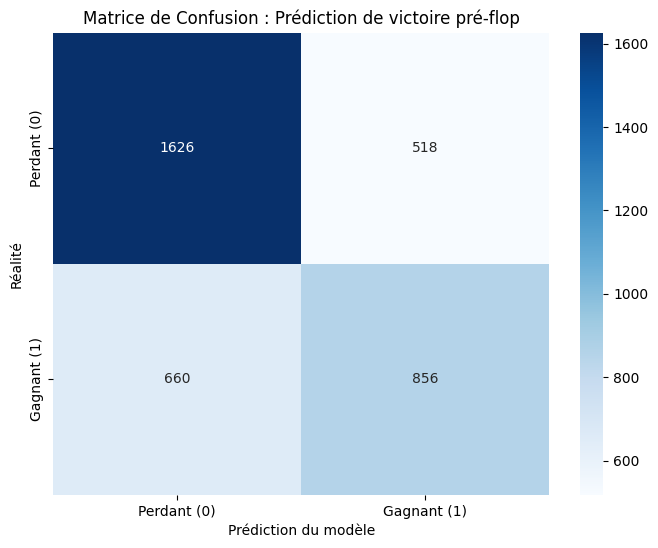

In [ ]:
def matrice_confusion(hero):

    y_test_c, y_pred_c = classification(hero)

    cm = confusion_matrix(y_test_c, y_pred_c)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Perdant (0)', 'Gagnant (1)'],
                yticklabels=['Perdant (0)', 'Gagnant (1)'])

    plt.xlabel('Prédiction du modèle')
    plt.ylabel('Réalité')
    plt.title('Matrice de Confusion : Prédiction de victoire pré-flop')
    plt.show()

matrice_confusion('MathisKcr')